Kapitel 1

Uppgift 11:

In [4]:
#egen kod för att förklara uppgiften, jag har valt dataseten salary_dataset.csv från övningsuppgfiter 

import pandas as pd
from sklearn.model_selection import train_test_split

# Läser in data samt kollar om vi datan fungerar vilket det gör
df = pd.read_csv("salary_dataset.csv")
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [5]:
# Delar upp datan i X och y
X = df[["YearsExperience"]]
y = df["Salary"]

# Första split: 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Andra split: 25% av train_full till val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42)

# Här visar vi proportioner
total = len(df)

print("Train:", len(X_train)/total)
print("Validation:", len(X_val)/total)
print("Test:", len(X_test)/total)

Train: 0.6
Validation: 0.2
Test: 0.2


Förklaringen till frågan är då att första uppdelningen så används test_size=0.2 vilket innebär att 20% av all data läggs in i textmängden och då finns 80% kvar av datan i X_train_full och y_train_full. Nästa steg delas de återstående mängd upp igen med test size=0.25. Vilket innebär 25% av 80% som återstod efter första delningen. 25% av 80% blir då 20 % av hela datan och då blir validering mängden 20%. Det som finns kvar är då 75% av 80% vilket är 60% av hela datan. Det är därför slutresultatet blir 60% träningsdata, 20 % valideringsdata och 20% testdata.


Kapitel 2

Uppgift 8: 

In [6]:
#Detta är kodningen från övningen


#Här importera vi biliotek för att kunna skapa en dataset, och använda modellen linear regression och joblib för att kunna spara och ladda modellen
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from joblib import dump, load

#här skapar vi en dataset med 20 tusen observationer med 3 variablar
X, y = make_regression(n_samples=20000, n_features=3, noise=0.1)

#Här använder vi modellen linearregression som datan ska tränas på med sambandet mellan x och y
model = LinearRegression().fit(X, y)

#här sparas modellen och laddas igen utan att behöva träna dataset igen
dump(model, "linear_model.joblib")
model_loaded = load("linear_model.joblib")

#här använder vi modellen för att prediktera värden, i detta fallet dom första 5 värdena
print(model_loaded.predict(X[:5]))

[ -26.33120043   15.41626569  -78.18309315 -165.18545137 -172.39295896]


Förklaring:

Det är viktigt att spara en model i praktiska fall eftersom det spara tid och resurser då träning av modeller är tridskrävander när det kommer till stora dataset och komplexa modeller. Man ska även kunna använda modellen i en app eller webbplats och då ska man kunna ladda en färdigtränad modell och använda den direkt. Koden som finns i övningen då visar processen från att skapa en data till att använda den färdiga modellen genom att spara och ladda modellen.

Kapitel 2

uppgift 9:

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

#a) Här läser vi in datasetet och dubbel kolla om läsningen fungerar.
df = pd.read_csv("data_01.csv")
df.head()

,x1,x2,x3,x4,x5,target
0,0.743487,1.072825,1.332911,-1.244771,0.344978,220.173943
1,0.835264,0.202184,0.966480,0.745883,-0.033773,175.873929
2,-1.103234,0.030615,-0.140385,0.727683,-2.831224,-162.270054
3,1.210186,1.685258,-0.394123,0.719024,-2.166585,165.930461
4,0.474577,0.647737,-0.451812,-0.409472,-0.051473,43.250511


In [8]:
#b) Här delar vi upp i X och y
X = df.drop(columns="target")
y = df["target"]

In [9]:
# c) här tränar vi upp datan genom att först dela 20% av hela datasetet till en testset och sedan delar vi upp de resterande 80% till tränings data och valideringsdata
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# de resterdande 15% av 80% används nu som valideringsdata 
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

In [10]:
# d) här används det 2 modeller, i detta fallet linearregression och decisiontreeregressor på träningsdatan
model_lr = LinearRegression()
model_tree = DecisionTreeRegressor(random_state=42)

model_lr.fit(X_train, y_train)
model_tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [11]:
#e) här utvärdera modellerna på resultatet av valideringsdatan vi använder oss då av RMSE flr att visa hur mycket stora fel det finns - lägre RMSE betyder bättre modell

pred_lr = model_lr.predict(X_val)
pred_tree = model_tree.predict(X_val)

rmse_lr = root_mean_squared_error(y_val, pred_lr)
rmse_tree = root_mean_squared_error(y_val, pred_tree)

print("Validering:")
print("LinearRegression RMSE:", rmse_lr)
print("DecisionTree RMSE:", rmse_tree)

Validering:
LinearRegression RMSE: 3.592300959691076
DecisionTree RMSE: 99.3594190386419


In [12]:
#f) Här används en if sats för att välja den bästa modellen
if rmse_lr < rmse_tree:
    best_model = LinearRegression()
    best_name = "LinearRegression"
else:
    best_model = DecisionTreeRegressor(random_state=42)
    best_name = "DecisionTree"
    
# Träna den bästa modellen på train + val
best_model.fit(X_train_full, y_train_full)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
#g) Testa på testdata
pred_test = best_model.predict(X_test)
rmse_test = root_mean_squared_error(y_test, pred_test)

print("\nBästa modell:", best_name)
print("Test RMSE:", rmse_test)


Bästa modell: LinearRegression
Test RMSE: 3.371549077515562


In [14]:
#h) Träna på hela datasetet
best_model.fit(X, y)

print("\nBästa modellen är nu tränad på hela datasetet.")


Bästa modellen är nu tränad på hela datasetet.


Kapitel 2

Uppgift 10:

In [15]:
#Här importera vi bibliotek

import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

# a)Läser in dataset och konfirmera att läsningen fungera
df = pd.read_csv("salary_dataset.csv")
print(df.head())


   YearsExperience   Salary
0              1.2  39344.0
1              1.4  46206.0
2              1.6  37732.0
3              2.1  43526.0
4              2.3  39892.0


In [16]:
#här delar vi upp dataset i x och y 
X = df[["YearsExperience"]]
y = df["Salary"]

In [17]:
# b) Dela upp datasetet i tränings- och testset där 20% går till test och 80% till train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:
# c) Här använder vi två modeller , linnear regression och decisiontreeregressor
model_lr = LinearRegression()                  
model_tree = DecisionTreeRegressor(random_state=42) 

#Kör korsvalidering med delning på 5 delar på båda modeller
cv_lr = cross_validate(
    model_lr,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"  
)

cv_tree = cross_validate(
    model_tree,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

#Här beräknar vi medelvärdet av resultaten
mean_lr = cv_lr["test_score"].mean()
mean_tree = cv_tree["test_score"].mean()


print("LinearRegression:", mean_lr)
print("DecisionTree:", mean_tree)

LinearRegression: -5293.203196998775
DecisionTree: -5611.57858424216


In [19]:
# d) Som förra övningen så använder vi en if sats för att välja den bästa modellen, men eftersom det är negativ RMSE så är högre bättre 
if mean_lr > mean_tree:
    best_model = LinearRegression()
    best_name = "LinearRegression"
else:
    best_model = DecisionTreeRegressor(random_state=42)
    best_name = "DecisionTree"
    
# Träna bästa modellen på hela träningsdatan
best_model.fit(X_train, y_train)

# Gör prediktioner på testdata
y_pred = best_model.predict(X_test)

# Beräkna RMSE (riktigt värde som är inte negativt)
rmse = root_mean_squared_error(y_test, y_pred)

print("\nBästa modell:", best_name)
print("Test RMSE:", rmse)


Bästa modell: LinearRegression
Test RMSE: 7059.043621901506


Kapitel 2

Uppgift 11:

In [20]:
#här importera vi bibliotek
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# a) Läser in mpg-datasetet från seaborn och konfirmera om läsningen fungera
df = sns.load_dataset("mpg")
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [21]:
# b) Ta bort rader med saknade värden enligt uppgiften
df = df.dropna()

# c) här droppa vi kolumnen name
df = df.drop(columns=["name"])

In [22]:
# d) Här gör vi om origin till siffror från text för att modellen ska kunna förstå datan. drop_first=True gör att vi får 2 nya kolumner istället för 3
 
df = pd.get_dummies(df, columns=["origin"], drop_first=True)



In [23]:
#  e) Här delar vi upp datasetet i X och y.
X = df.drop(columns=["mpg"])
y = df["mpg"]

In [24]:
# f) Som förregående uppgifter så delar vi upp det till träningsdata och testdata

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 313
Test: 79


In [25]:
# g) Här tränar vi en linjär regressionsmodell
model = LinearRegression()
model.fit(X_train, y_train)

# Gör sedan prediktioner på testdata
y_pred = model.predict(X_test)

# Utvärdera modellen
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)   

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 3.2561
R²: 0.7923


Kapitel 2

Uppgift 12: om jag hinner

Kapitel 3

Uppgift 13:

In [26]:
#här importera vi bilioteket

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Läs in datasetet och konfirmera om läsningen fungera korrekt
df = pd.read_excel("HR_Employee_Data.xlsx")
print(df.head())




     Emp_Id  satisfaction_level  last_evaluation  number_project  \
0  IND02438                0.38             0.53               2   
1  IND28133                0.80             0.86               5   
2  IND07164                0.11             0.88               7   
3  IND30478                0.72             0.87               5   
4  IND24003                0.37             0.52               2   

   average_montly_hours  time_spend_company  Work_accident  left  \
0                   157                   3              0     1   
1                   262                   6              0     1   
2                   272                   4              0     1   
3                   223                   5              0     1   
4                   159                   3              0     1   

   promotion_last_5years Department  salary  
0                      0      sales     low  
1                      0      sales  medium  
2                      0      sales  medium 

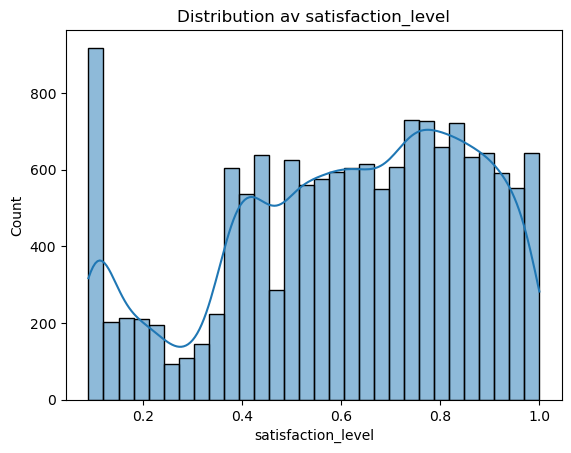

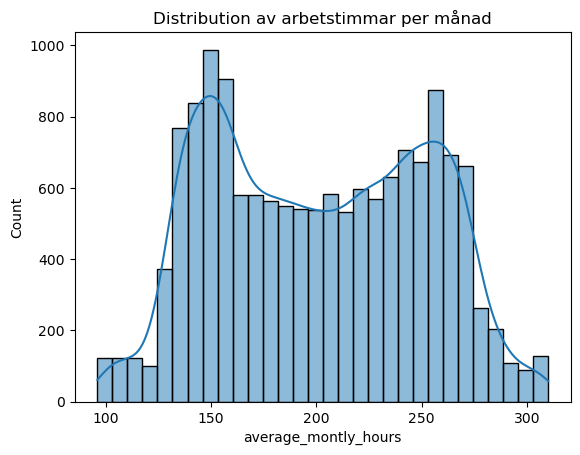

In [27]:
#här fördelar vi satisfaction_level och satisfaction_level och visar grafen på det

sns.histplot(df["satisfaction_level"], kde=True)
plt.title("Distribution av satisfaction_level")
plt.show()

sns.histplot(df["average_montly_hours"], kde=True)
plt.title("Distribution av arbetstimmar per månad")
plt.show()

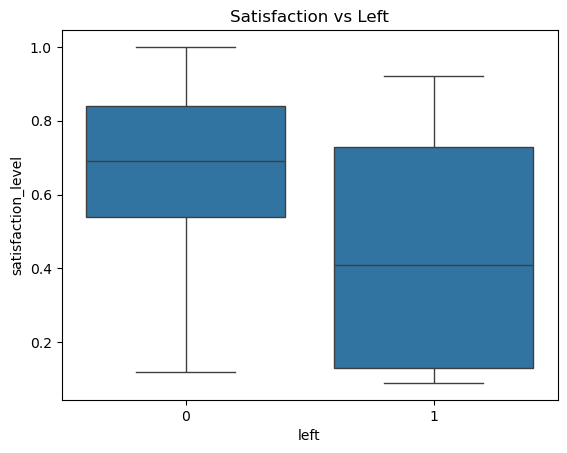

In [28]:
# Jämför satisfaction mellan de som lämnat vilket är nummer 1 och de som stannat som är nummer 0 och sedan visar grafen


sns.boxplot(x="left", y="satisfaction_level", data=df)  

plt.title("Satisfaction vs Left")  

plt.show()  


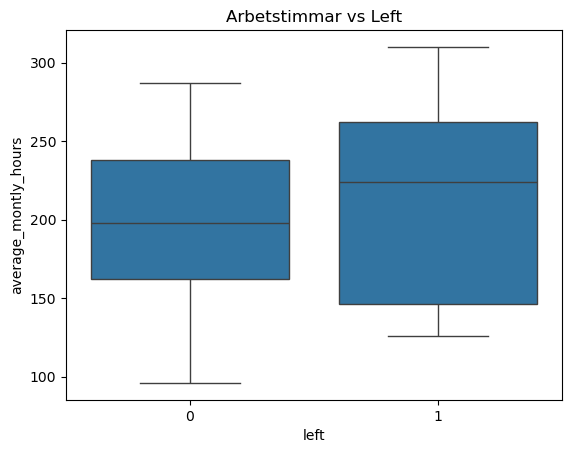

In [29]:
# här Jämför vi arbetstimmar mellan grupperna, 0 och 1 är samma som ovanför, där 0 är de som har stannat och 1 är de osm lämnat

sns.boxplot(x="left", y="average_montly_hours", data=df)  


plt.title("Arbetstimmar vs Left")  


plt.show()  


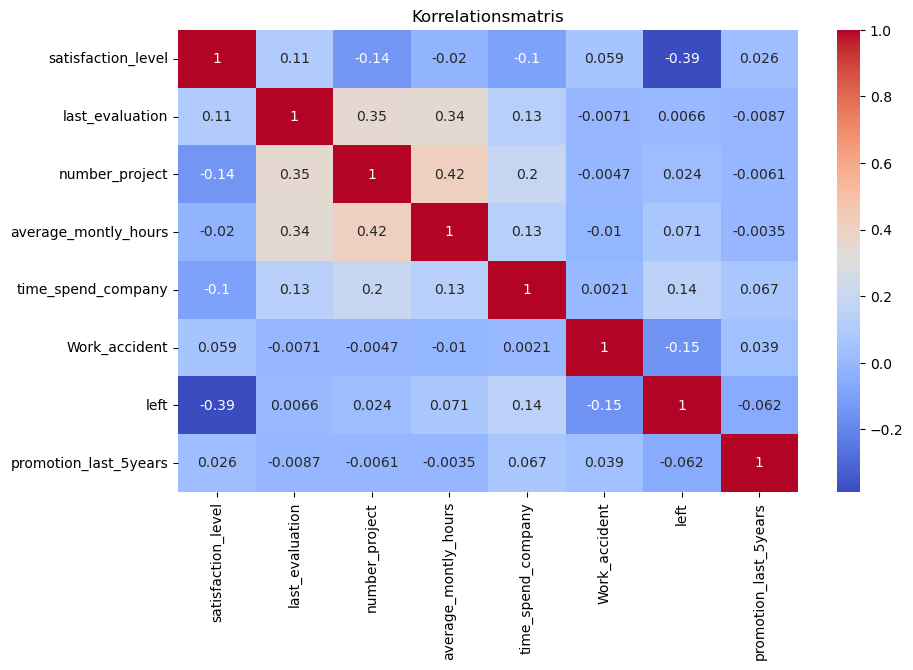

In [30]:
plt.figure(figsize=(10,6))

# Här Väljer vi bara numeriska kolumner
numeric_df = df.select_dtypes(include=["number"])

# Skapar korrelationsmatris för numeriska variabler
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Korrelationsmatris")
plt.show()

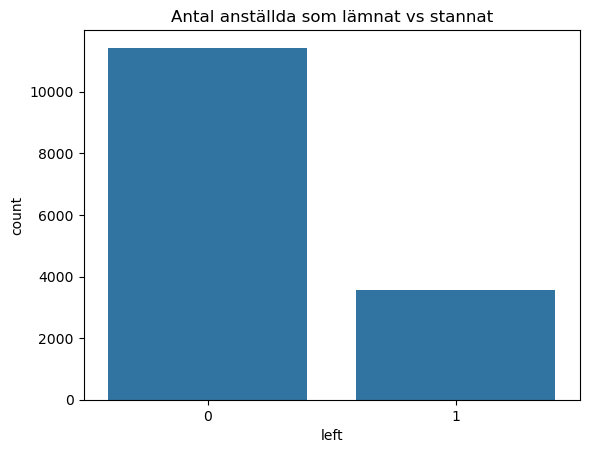

In [31]:
# Här räknar vi ut hur många som lämnat vs stannat

sns.countplot(x="left", data=df)  

plt.title("Antal anställda som lämnat vs stannat")  

plt.show()  


Kapitel 3

Uppgift 14:

In [32]:
#här importera vi biliotek

import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score


#kod från uppgiften

# This code is merely executed to see the description of 
# ↪ the data in a smooth way
data = load_diabetes()
print(data.DESCR)
# Storing/loading the data the way it will be used
X, y = load_diabetes(return_X_y=True, as_frame=True)
print(X.info())
print(y.info())
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)

#vi delar alltså upp datan i tränings data och test data där 80% används för träning och 20% för test




.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [33]:
#Här skapar vi en linjär regressionsmodell och träna modellen på träningsdatan samt att den gör prediktioner på testdatan. 
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Beräknar RMSE för att se hur stora felen är i genomsnitt och R² för att se hur stor del av variationen modellen förklarar
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 53.8534
R²: 0.4526


Kapitel 3

Uppgift 15a:

In [83]:
#importering av biliotek
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

#läser in dataset och konfirmera om läsningen fungerar
df = pd.read_csv("car_price_dataset.csv", sep=";")
print(df.head())



#här kollar vi även om det finns saknande värden och ta bort rader med saknande värden
print(df.isna().sum())
df = df.dropna()

# vi delar upp i X och y
X = df.drop(columns="Price")
y = df["Price"]

# Här identifierar vi vilka kolumner som är kategoriska och numeriska
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("\nKategoriska kolumner:")
print(categorical_cols)

print("\nNumeriska kolumner:")
print(numerical_cols)

# Delar upp datan som förregående uppgifter i tränings- och testdata 80% används för träning och 20% för test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Här skapar en preprocessing-del OneHotEncoder omvandlar kategoriska variabler till numerisk form och sedan skapar vi en pipe line som preprocessar datan och sedan tränas modellen
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"  
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

# till slut tränar vi modellen på träningsdatan och sedan gör prediktioner på testdatan
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Beräknar RMSE för att se hur stora felen är i genomsnitt och R² för att se hur stor del av variationen modellen förklarar

rmse = root_mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

import joblib
joblib.dump(model, "car_price_model.joblib")
 

        Brand   Model  Year  Engine_Size Fuel_Type    Transmission  Mileage  \
0         Kia     Rio  2020          4.2    Diesel          Manual   289944   
1   Chevrolet  Malibu  2012          2.0    Hybrid       Automatic     5356   
2    Mercedes     GLA  2020          4.2    Diesel       Automatic   231440   
3        Audi      Q5  2023          2.0  Electric          Manual   160971   
4  Volkswagen    Golf  2003          2.6    Hybrid  Semi-Automatic   286618   

   Doors  Owner_Count  Price  
0      3            5   8501  
1      2            3  12092  
2      4            2  11171  
3      2            1  11780  
4      3            3   2867  
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

Kategoriska kolumner:
Index(['Brand', 'Model', 'Fuel_Type', 'Transmission'], dtype='object')

Numeriska kolumner:
Index(['Year', 'Engine_Size', '

['car_price_model.joblib']

In [41]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


Kapitel 3

Uppgift 15b: Finns i en annan vscode python fil.

In [84]:
#uppgift 15b

#importera biliotek
import pandas as pd
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder 
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


st.title("Bilpris-prediktion")
st.write("Fyll i information om bilen för att få ett predikterat pris.")

# Läser in datasetet
df = pd.read_csv("car_price_dataset.csv", sep=";")

# Tar bort  mellanslag i kolumnnamn
df.columns = df.columns.str.strip()

# Tar bort rader med saknade värden
df = df.dropna()

# vi delar upp i X och y
X = df.drop(columns="Price")
y = df["Price"]

# Här identifierar vi vilka kolumner som är kategoriska och numeriska
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

# Här skapar en preprocessing-del OneHotEncoder omvandlar kategoriska variabler till numerisk form och sedan skapar vi en pipe line som preprocessar datan och sedan tränas modellen
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"  
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])


# Tränar modellen på all data
model.fit(X, y)


brand = st.selectbox("Välj bilmärke", sorted(df["Brand"].unique()))
model_name = st.selectbox("Välj modell", sorted(df["Model"].unique()))
year = st.number_input("Årsmodell", min_value=int(df["Year"].min()), max_value=int(df["Year"].max()), value=int(df["Year"].median()))
engine_size = st.number_input("Motorstorlek", min_value=float(df["Engine_Size"].min()), max_value=float(df["Engine_Size"].max()), value=float(df["Engine_Size"].median()))
fuel_type = st.selectbox("Bränsletyp", sorted(df["Fuel_Type"].unique()))
transmission = st.selectbox("Växellåda", sorted(df["Transmission"].unique()))
mileage = st.number_input("Miltal / körsträcka", min_value=int(df["Mileage"].min()), max_value=int(df["Mileage"].max()), value=int(df["Mileage"].median()))
doors = st.number_input("Antal dörrar", min_value=int(df["Doors"].min()), max_value=int(df["Doors"].max()), value=int(df["Doors"].median()))
owner_count = st.number_input("Antal tidigare ägare", min_value=int(df["Owner_Count"].min()), max_value=int(df["Owner_Count"].max()), value=int(df["Owner_Count"].median()))

# Skapar en DataFrame med användarens inmatning
input_data = pd.DataFrame({
    "Brand": [brand],
    "Model": [model_name],
    "Year": [year],
    "Engine_Size": [engine_size],
    "Fuel_Type": [fuel_type],
    "Transmission": [transmission],
    "Mileage": [mileage],
    "Doors": [doors],
    "Owner_Count": [owner_count]
})

# En knapp för att göra prediktion
if st.button("Prediktera pris"):
    prediction = model.predict(input_data)[0]
    st.success(f"Predikterat pris: {prediction:,.2f}")

2026-04-02 10:26:50.062 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:26:50.079 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:26:50.087 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:26:50.105 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:26:50.109 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:26:50.111 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:27:47.861 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:27:47.868 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Kapitel 3

Uppgift 15c:

Ja det hade kunnats använda i verkligheten, denna modellen och applikation hade kunnat användas av försäkringsbolag, digitala bilplatformar eller även bilhandlare för att uppskatta marknadsvärdet på en bil. Privat personer kan också få en snabb indikation på värden av en bil.

Kapitel 4

Uppgift 11:


In [ ]:
#här importera vi från bilioteket, classification report som är då en funktion som visar hur bra en klassificeringsmodell är 
from sklearn.metrics import classification_report

#y_true är då de riktiga klasserna medans y_pred är de som modellen gissade 
y_true = [0, 1, 2, 2, 2]
y_pred = [0, 0, 2, 2, 1]

#här har vi då namn på våra klasser 
target_names = ['class 0', 'class 1', 'class 2']

#här skapar vi en rapport som visar då precision, recall, f1-score och support
print(classification_report(y_true, y_pred,
target_names=target_names))

#som helhet använder vi classification_report för att utvärdera en klassificationsmodell genom att jämföra de riktiga värdena med modellens prediktioner.
#vi ser då att class 2 har alla prediktioner korrekta eftersom precision är på 1 som är 100 procent medans class 0 har  recall på 1.00, vilket innebär att modellen hittar alla verkliga exempel av denna klass.
#men precisionen 0.50, vilket betyder att modellen även gör felaktiga prediktioner för klass 0.
#precisionen 0.50, vilket betyder att modellen även gör felaktiga prediktioner för klass 0. Den totala accuracy är 0.60, vilket innebär att modellen gör rätt i 60% av fallen.

              precision    recall  f1-score   support

     class 0       0.50      1.00      0.67         1
     class 1       0.00      0.00      0.00         1
     class 2       1.00      0.67      0.80         3

    accuracy                           0.60         5
   macro avg       0.50      0.56      0.49         5
weighted avg       0.70      0.60      0.61         5



Kapitel 4

Uppgift 12:

In [57]:
#importera biliotek

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [58]:
#här laddar vi in dataset och sedan skapa och träna modellen

X, y = load_iris(return_X_y=True, as_frame=True)
iris = load_iris()

model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

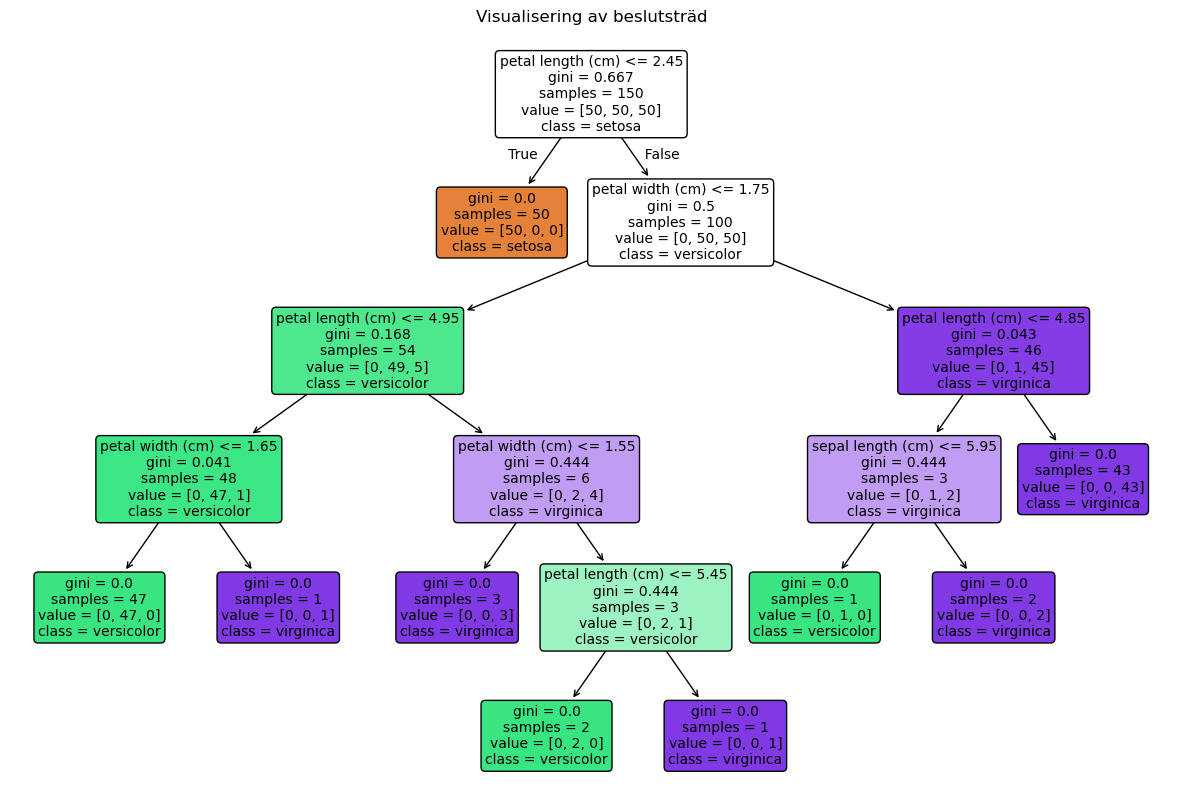

In [63]:
#här visualisera vi beslutsträdet
plt.figure(figsize=(15, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Visualisering av beslutsträd")
plt.show()

Kapitel 4

Uppgift 13:

In [66]:
#importera biliotek

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#läser in filen och konfirmera att läsningen fungerar
df = pd.read_excel("HR_Employee_Data.xlsx")
print(df.head())

     Emp_Id  satisfaction_level  last_evaluation  number_project  \
0  IND02438                0.38             0.53               2   
1  IND28133                0.80             0.86               5   
2  IND07164                0.11             0.88               7   
3  IND30478                0.72             0.87               5   
4  IND24003                0.37             0.52               2   

   average_montly_hours  time_spend_company  Work_accident  left  \
0                   157                   3              0     1   
1                   262                   6              0     1   
2                   272                   4              0     1   
3                   223                   5              0     1   
4                   159                   3              0     1   

   promotion_last_5years Department  salary  
0                      0      sales     low  
1                      0      sales  medium  
2                      0      sales  medium 

In [67]:
# Tar bort rader med saknade värden
df = df.dropna()

# Här delar upp i X och y
# y är målvariabeln left: 1 = har lämnat, 0 = jobbar kvar
X = df.drop(columns="left")
y = df["left"]

In [68]:
#Här identifierar vi kategoriska och numeriska kolumner
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

#Här delar upp vi datan i träning och testdata där 80% används för träning och 20% för test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [69]:
#Här skapar preprocessing för kategoriska variabler. OneHotEncoder omvandlar text till numerisk form
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"  # Behåller numeriska kolumner som de är
)

#sedan skapar vi en pipeline som först preprocessas datan, sedan tränas modellen
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [70]:
#Här tränar modellen på träningsdatan
model.fit(X_train, y_train)

#Sedan gör den prediktioner på testdatan
y_pred = model.predict(X_test)

#och beräknar accuracy
accuracy = accuracy_score(y_test, y_pred)

#Här skriver vi  ut resultat
print("\nAccuracy på testdata:")
print(f"{accuracy:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy på testdata:
0.9777

Classification report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2294
           1       0.98      0.92      0.95       706

    accuracy                           0.98      3000
   macro avg       0.98      0.96      0.97      3000
weighted avg       0.98      0.98      0.98      3000


Confusion matrix:
[[2284   10]
 [  57  649]]


Kapitel 4 

Uppgift 14:

In [71]:
#här importerar vi biliotek

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Läser in Iris-datasetet och skriver ut beskrivningen av datasettet och dess klasser
iris = load_iris()
print(iris.DESCR)    
print(iris.DESCR)    



.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [73]:
#här laddar vi in data som pandas objekt och väljer 2 variabler för att göra visualiseringen enklare
X, y = load_iris(return_X_y=True, as_frame=True)
X = X[['sepal length (cm)', 'sepal width (cm)']]

#Som vanligt delar vi först upp datan i train_full och testdata 20% används som testdata
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40
)

#sedan delar vi train_full i träningsdata och valideringsdata, 30% av train_full blir valideringsdata
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.3, random_state=36
)


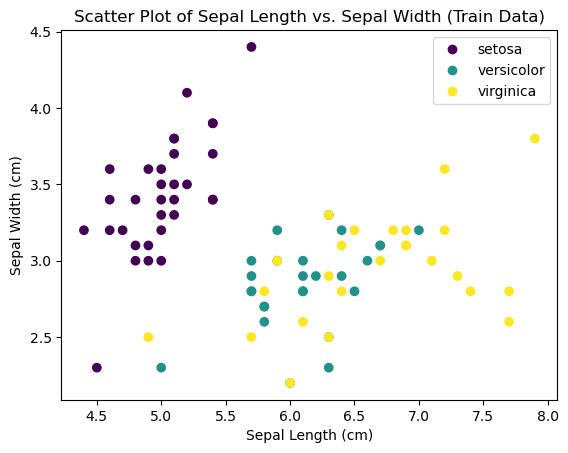

In [74]:
# Kodningen finns på övningen
classes = ['setosa', 'versicolor', 'virginica']

scatter = plt.scatter(
    X_train['sepal length (cm)'],
    X_train['sepal width (cm)'],
    c=y_train
)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width (Train Data)')

plt.legend(handles=scatter.legend_elements()[0], labels=classes)

plt.show()

In [75]:
#här skapar vi en beslutsträd och tränar sedan på modellen som vi sedan gör prediktioner på valideringsdatan och beräkna accuracy på den

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"{val_accuracy:.4f}")


0.6389


In [76]:
#Här tränar vi om modellen på både träning och valideringsdatan och som innan gör vi prediktioner på testdatan och beräkna accuracy på den
model.fit(X_train_full, y_train_full)
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"{test_accuracy:.4f}")

0.7333


In [77]:
# Skriver ut en klassificeringsrapport och confusion matrix
print("\nClassification report:")
print(classification_report(y_test, y_test_pred, target_names=classes))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred))


Classification report:
              precision    recall  f1-score   support

      setosa       0.89      1.00      0.94         8
  versicolor       0.67      0.67      0.67        12
   virginica       0.67      0.60      0.63        10

    accuracy                           0.73        30
   macro avg       0.74      0.76      0.75        30
weighted avg       0.73      0.73      0.73        30


Confusion matrix:
[[8 0 0]
 [1 8 3]
 [0 4 6]]


In [78]:
#vi skapar en tabell med verkliga och predikterade värden
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

print(results.head())

   Actual  Predicted
0       0          0
1       1          1
2       2          1
3       2          2
4       1          1
